# AI Job Market Analysis (2025–2026)

**Objective:** Explore and analyse the global AI job market to uncover trends in salaries, in-demand skills, remote work patterns, and growth across industries and roles.

**Dataset:** 1,500 AI job listings across 14 countries, 12 industries, and 25 features including salary data, demand metrics, and required skills.

---

### Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview & Quality Check](#2)
3. [Data Cleaning & Preparation](#3)
4. [Exploratory Data Analysis](#4)
   - 4.1 Salary Analysis
   - 4.2 Skills Analysis
   - 4.3 Geographic & Remote Work Analysis
   - 4.4 Demand & Growth Trends
   - 4.5 LLM Roles Deep Dive
5. [Key Takeaways](#5)

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.1f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Custom colour palette for consistent styling
PALETTE = ['#2563eb', '#f59e0b', '#10b981', '#ef4444', '#8b5cf6', '#ec4899']
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load the dataset
df = pd.read_csv('ai_jobs_market_2025_2026.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 1500 rows × 25 columns


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,"239,000.0",155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,"166,000.0",90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,"360,000.0",160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,"161,000.0",130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,"283,000.0",140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


<a id='2'></a>
## 2. Data Overview & Quality Check

In [4]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [5]:
# Statistical summary for numerical columns
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,"1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0","1,500.0"
mean,6.2,"194,892.0","135,448.7","257,537.3",10.9,87.5,31.1,7.9,"2,025.6",4.0,0.5,0.8,0.2
std,2.7,"66,506.8","24,449.0","39,852.8",4.0,8.0,22.0,1.1,0.5,3.3,0.5,0.4,0.4
min,1.0,"90,000.0","90,000.0","180,000.0",3.0,68.0,5.0,6.0,"2,025.0",1.0,0.0,0.0,0.0
25%,4.0,"144,750.0","120,000.0","218,000.0",8.2,82.0,15.4,6.9,"2,025.0",2.0,0.0,1.0,0.0
50%,6.0,"180,000.0","140,000.0","270,000.0",10.5,89.0,23.4,7.9,"2,026.0",3.0,0.0,1.0,0.0
75%,8.0,"236,250.0","155,000.0","290,000.0",14.2,95.0,42.7,8.9,"2,026.0",5.0,1.0,1.0,0.0
max,15.0,"384,000.0","180,000.0","320,000.0",18.0,98.0,87.8,9.8,"2,026.0",12.0,1.0,1.0,1.0


In [6]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


In [7]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate job IDs: {df["job_id"].duplicated().sum()}')

Duplicate rows: 0
Duplicate job IDs: 0


In [8]:
# Quick look at unique values per categorical column
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(f'  → {df[col].value_counts().head(3).to_dict()}\n')

job_id: 1500 unique values
  → {'AIJOB0001': 1, 'AIJOB0998': 1, 'AIJOB1007': 1}

job_title: 25 unique values
  → {'LLM Engineer': 75, 'Robotics Engineer (AI)': 74, 'Generative AI Engineer': 71}

job_category: 12 unique values
  → {'AI Engineering': 736, 'Data Science': 127, 'Governance': 122}

experience_level: 4 unique values
  → {'Entry (0-2 yrs)': 385, 'Lead (10+ yrs)': 381, 'Mid (3-5 yrs)': 370}

education_required: 5 unique values
  → {"Master's": 316, "Bachelor's": 311, 'Bootcamp/Self-taught': 297}

city: 20 unique values
  → {'San Francisco': 92, 'London': 90, 'Beijing': 87}

country: 14 unique values
  → {'USA': 515, 'UK': 90, 'China': 87}

remote_work: 3 unique values
  → {'Hybrid': 686, 'Fully Remote': 445, 'On-site': 369}

company_size: 5 unique values
  → {'Mid-size (501-5000)': 312, 'SME (51-500)': 300, 'Big Tech (FAANG+)': 299}

industry: 12 unique values
  → {'Automotive': 138, 'Healthcare': 138, 'Government': 136}

required_skills: 1500 unique values
  → {'APIs|Planning

<a id='3'></a>
## 3. Data Cleaning & Preparation

In [9]:
# Drop the job_id column (not useful for analysis)
df = df.drop(columns=['job_id'])

# Convert binary flags to readable labels
df['is_senior_label'] = df['is_senior'].map({1: 'Senior', 0: 'Non-Senior'})
df['is_remote_label'] = df['is_remote_friendly'].map({1: 'Remote-Friendly', 0: 'Not Remote-Friendly'})
df['is_llm_label'] = df['is_llm_role'].map({1: 'LLM Role', 0: 'Non-LLM Role'})

# Calculate salary range spread
df['salary_range'] = df['salary_max_usd'] - df['salary_min_usd']

# Parse the required_skills column into a list
df['skills_list'] = df['required_skills'].str.split('|')
df['num_skills'] = df['skills_list'].apply(len)

# Create a posting date column for time-based analysis
df['posting_date'] = pd.to_datetime(
    df['posting_year'].astype(str) + '-' + df['posting_month'].astype(str).str.zfill(2) + '-01'
)

print('Cleaning complete. New columns added:')
print('  → is_senior_label, is_remote_label, is_llm_label')
print('  → salary_range, skills_list, num_skills, posting_date')
print(f'\nFinal shape: {df.shape}')

Cleaning complete. New columns added:
  → is_senior_label, is_remote_label, is_llm_label
  → salary_range, skills_list, num_skills, posting_date

Final shape: (1500, 31)


<a id='4'></a>
## 4. Exploratory Data Analysis

### 4.1 Salary Analysis

Let's explore how salaries are distributed and what drives higher pay.

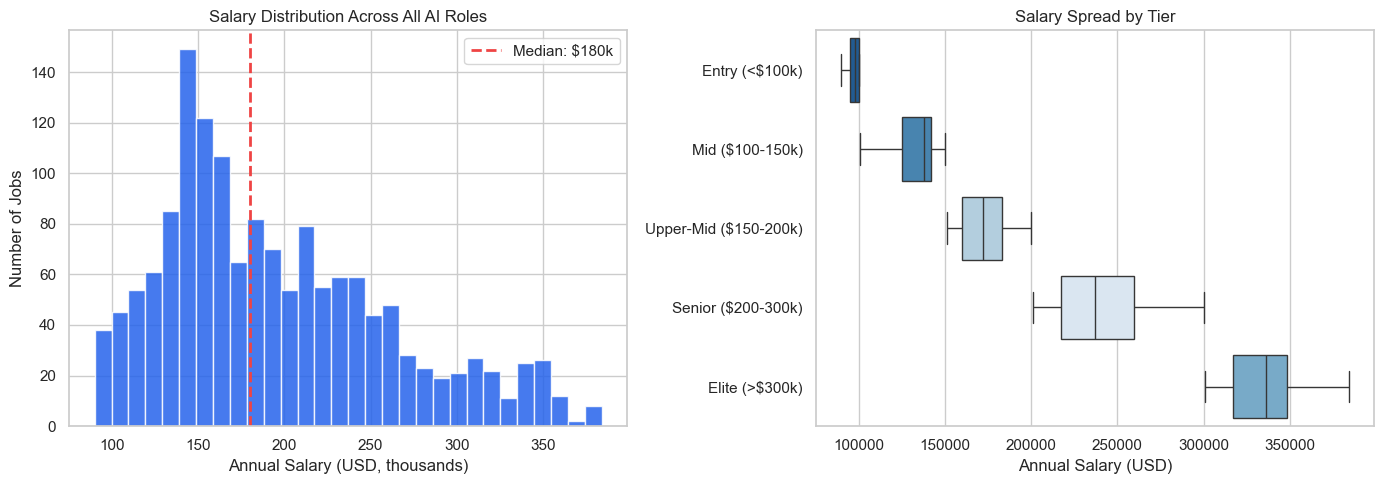

In [10]:
# Overall salary distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['annual_salary_usd'] / 1000, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['annual_salary_usd'].median() / 1000, color=PALETTE[3], linestyle='--', linewidth=2, label=f'Median: ${df["annual_salary_usd"].median()/1000:.0f}k')
axes[0].set_xlabel('Annual Salary (USD, thousands)')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('Salary Distribution Across All AI Roles')
axes[0].legend()

# Box plot by salary tier
tier_order = ['Entry (<$100k)', 'Mid ($100-150k)', 'Upper-Mid ($150-200k)', 'Senior ($200-300k)', 'Elite (>$300k)']
sns.boxplot(data=df, y='salary_tier', x='annual_salary_usd', hue='salary_tier', order=tier_order, palette='Blues', legend=False, ax=axes[1])
axes[1].set_xlabel('Annual Salary (USD)')
axes[1].set_ylabel('')
axes[1].set_title('Salary Spread by Tier')
plt.tight_layout()
plt.show()

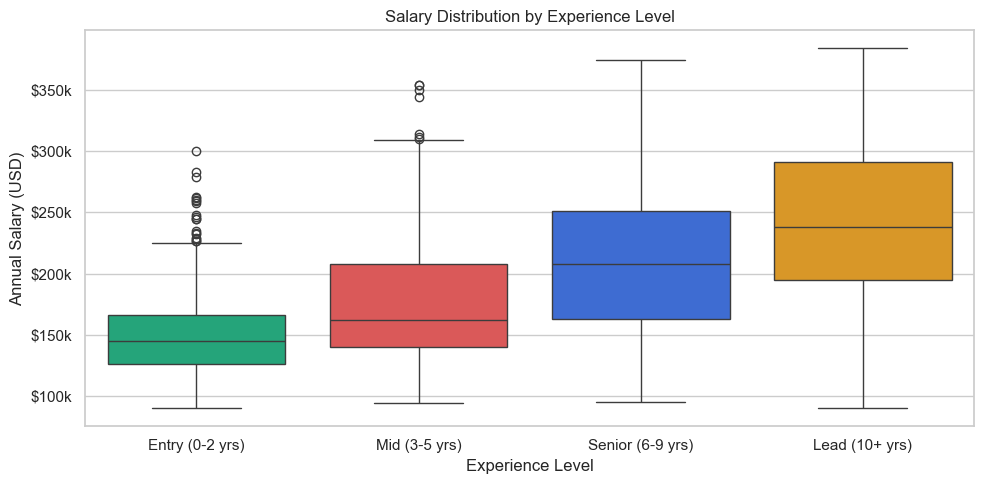

Median salary by experience level:
experience_level
Entry (0-2 yrs)     $145,000
Mid (3-5 yrs)       $162,000
Senior (6-9 yrs)    $208,000
Lead (10+ yrs)      $238,000
Name: annual_salary_usd, dtype: object


In [11]:
# Salary by experience level
exp_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='experience_level', y='annual_salary_usd',
    order=exp_order, hue='experience_level', palette=PALETTE[:4], legend=False, 
    ax=ax
)
ax.set_xlabel('Experience Level')
ax.set_ylabel('Annual Salary (USD)')
ax.set_title('Salary Distribution by Experience Level')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

# Print median salaries
print('Median salary by experience level:')
print(df.groupby('experience_level')['annual_salary_usd'].median().reindex(exp_order).apply(lambda x: f'${x:,.0f}'))

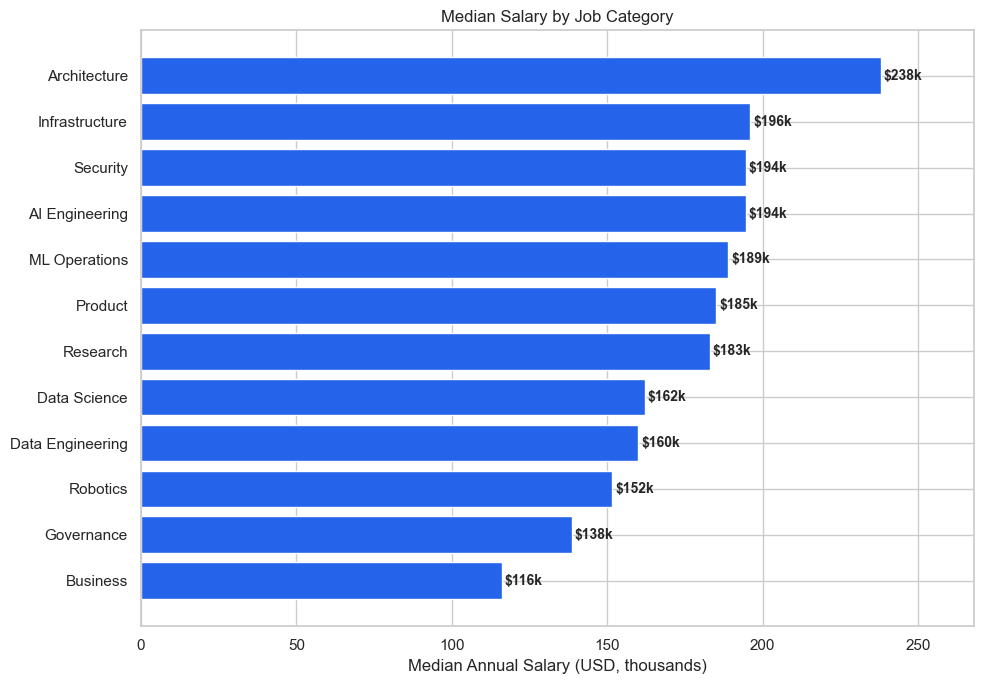

In [12]:
# Salary by job category — horizontal bar chart
cat_salary = df.groupby('job_category')['annual_salary_usd'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cat_salary.index, cat_salary.values / 1000, color=PALETTE[0], edgecolor='white')

# Add value labels
for bar, val in zip(bars, cat_salary.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'${val/1000:.0f}k', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median Annual Salary (USD, thousands)')
ax.set_title('Median Salary by Job Category')
ax.set_xlim(0, cat_salary.max() / 1000 + 30)
plt.tight_layout()
plt.show()

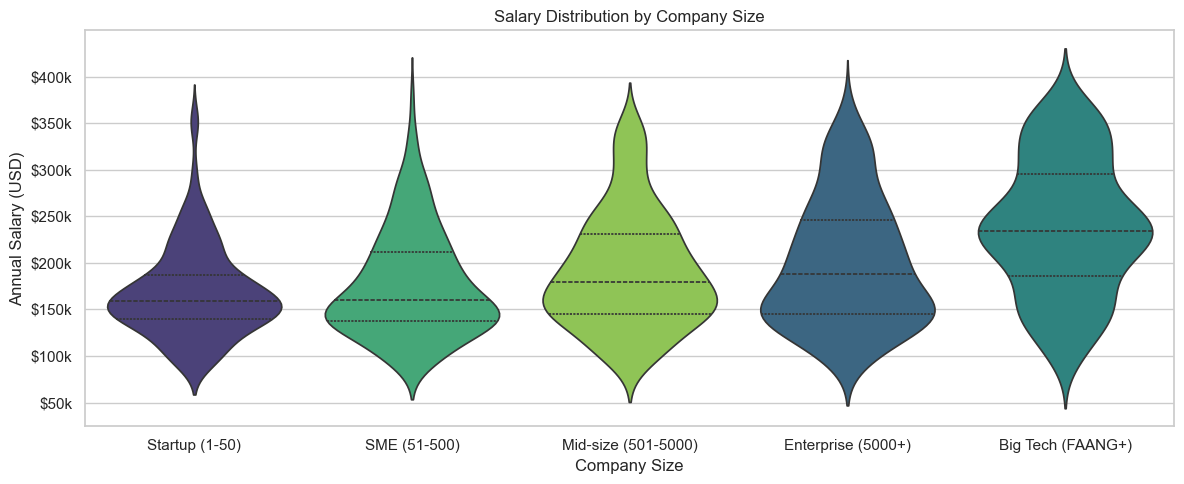

In [13]:
# Salary by company size
size_order = ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=df, x='company_size', y='annual_salary_usd',
    order=size_order, hue='company_size', palette='viridis', legend=False, ax=ax, inner='quartile'
)
ax.set_xlabel('Company Size')
ax.set_ylabel('Annual Salary (USD)')
ax.set_title('Salary Distribution by Company Size')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

### 4.2 Skills Analysis

Which skills are most in demand, and how do they relate to salary?

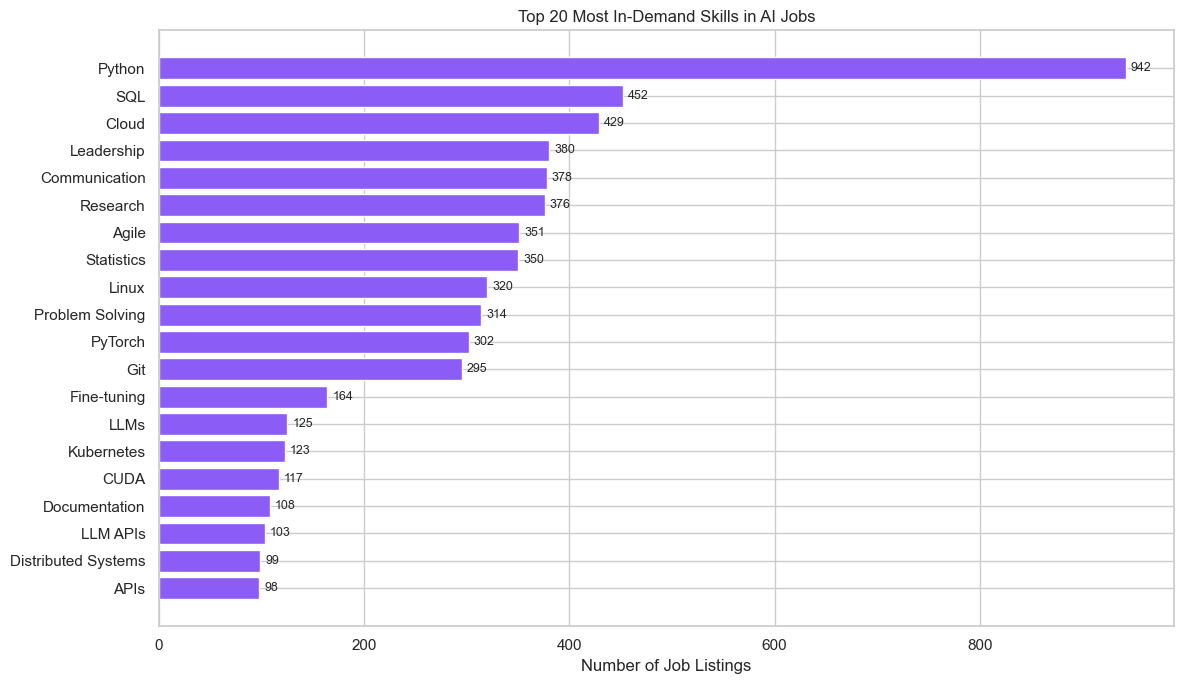

Python appears in 62.8% of all job listings.


In [14]:
# Explode skills and count frequency
skills_exploded = df.explode('skills_list')
skills_exploded['skills_list'] = skills_exploded['skills_list'].str.strip()

skill_counts = skills_exploded['skills_list'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(skill_counts.index[::-1], skill_counts.values[::-1], color=PALETTE[4], edgecolor='white')

# Add count labels
for bar, val in zip(bars, skill_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Job Listings')
ax.set_title('Top 20 Most In-Demand Skills in AI Jobs')
plt.tight_layout()
plt.show()

print(f'Python appears in {skill_counts["Python"]/len(df)*100:.1f}% of all job listings.')

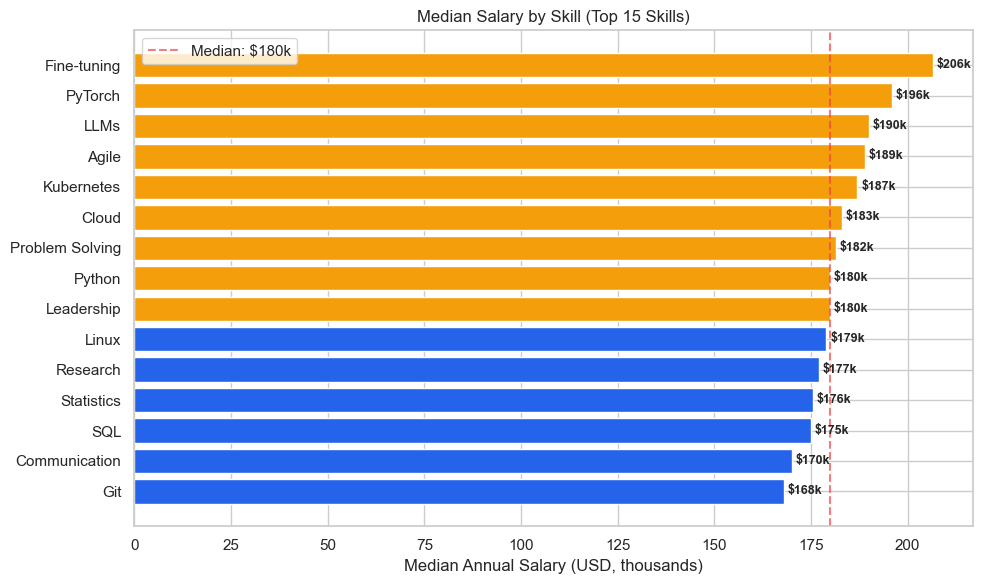

In [15]:
# Median salary by skill (top 15 skills only)
top_skills = skill_counts.head(15).index.tolist()
skill_salary = (
    skills_exploded[skills_exploded['skills_list'].isin(top_skills)]
    .groupby('skills_list')['annual_salary_usd']
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE[1] if val >= skill_salary.median() else PALETTE[0] for val in skill_salary.values]
ax.barh(skill_salary.index, skill_salary.values / 1000, color=colors, edgecolor='white')

for i, (skill, val) in enumerate(skill_salary.items()):
    ax.text(val / 1000 + 1, i, f'${val/1000:.0f}k', va='center', fontsize=9, fontweight='bold')

ax.axvline(skill_salary.median() / 1000, color=PALETTE[3], linestyle='--', alpha=0.7, label=f'Median: ${skill_salary.median()/1000:.0f}k')
ax.set_xlabel('Median Annual Salary (USD, thousands)')
ax.set_title('Median Salary by Skill (Top 15 Skills)')
ax.legend()
plt.tight_layout()
plt.show()

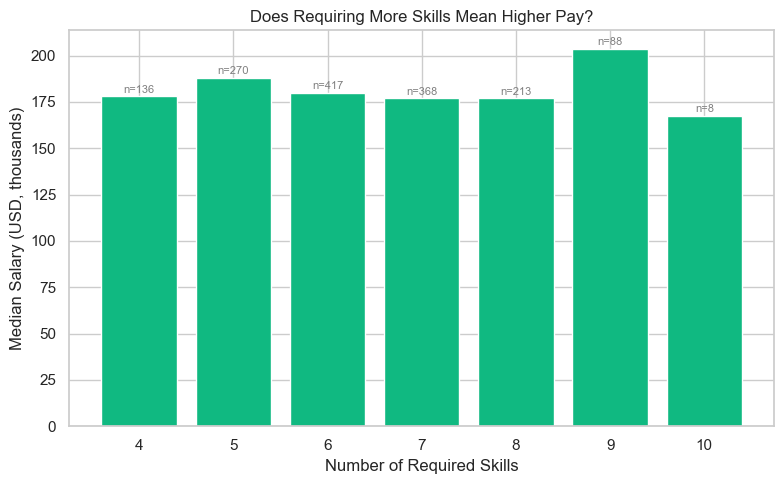

In [16]:
# Does having more skills listed correlate with higher salary?
fig, ax = plt.subplots(figsize=(8, 5))
skill_group = df.groupby('num_skills')['annual_salary_usd'].agg(['median', 'count']).reset_index()

ax.bar(skill_group['num_skills'], skill_group['median'] / 1000, color=PALETTE[2], edgecolor='white')
ax.set_xlabel('Number of Required Skills')
ax.set_ylabel('Median Salary (USD, thousands)')
ax.set_title('Does Requiring More Skills Mean Higher Pay?')
ax.set_xticks(skill_group['num_skills'])

# Add count annotations
for _, row in skill_group.iterrows():
    ax.text(row['num_skills'], row['median'] / 1000 + 2, f'n={int(row["count"])}',
            ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

### 4.3 Geographic & Remote Work Analysis

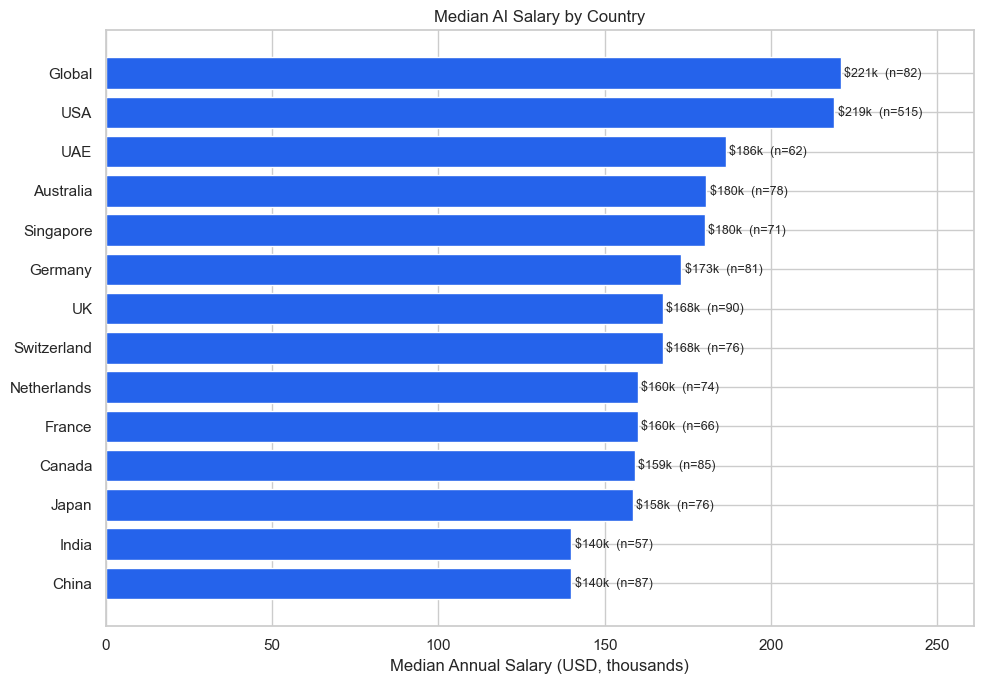

In [17]:
# Median salary by country
country_stats = df.groupby('country').agg(
    median_salary=('annual_salary_usd', 'median'),
    job_count=('annual_salary_usd', 'count')
).sort_values('median_salary', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(country_stats.index, country_stats['median_salary'] / 1000, color=PALETTE[0], edgecolor='white')

for bar, (_, row) in zip(bars, country_stats.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'${row["median_salary"]/1000:.0f}k  (n={int(row["job_count"])})',
            va='center', fontsize=9)

ax.set_xlabel('Median Annual Salary (USD, thousands)')
ax.set_title('Median AI Salary by Country')
ax.set_xlim(0, country_stats['median_salary'].max() / 1000 + 40)
plt.tight_layout()
plt.show()

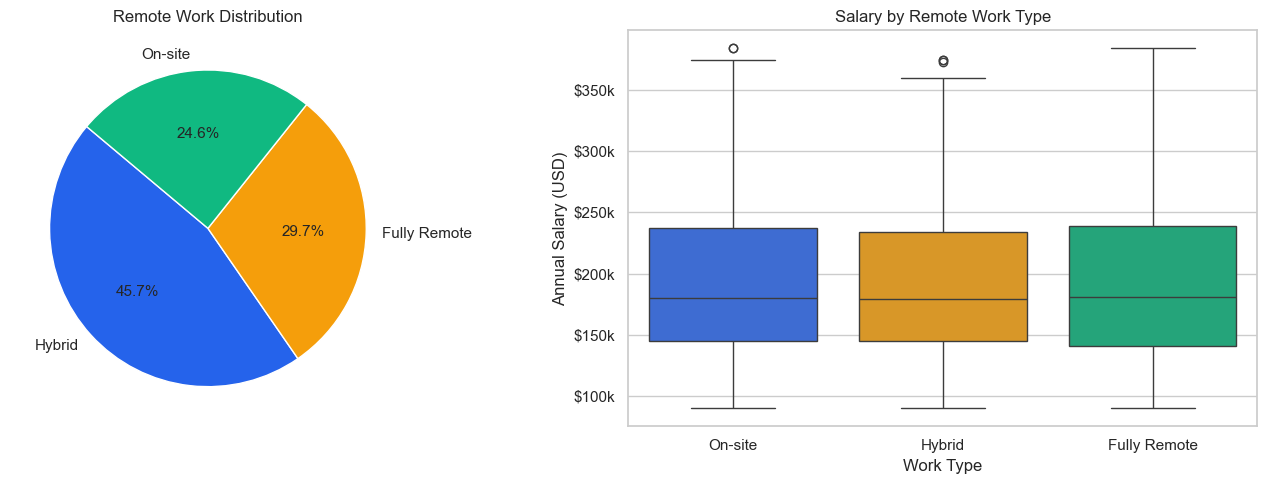

In [18]:
# Remote work distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall split
remote_counts = df['remote_work'].value_counts()
axes[0].pie(
    remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=140, textprops={'fontsize': 11}
)
axes[0].set_title('Remote Work Distribution')

# Salary by remote type
remote_order = ['On-site', 'Hybrid', 'Fully Remote']
sns.boxplot(
    data=df, x='remote_work', y='annual_salary_usd',
    order=remote_order, hue='remote_work', palette=PALETTE[:3], legend=False, ax=axes[1]
)
axes[1].set_xlabel('Work Type')
axes[1].set_ylabel('Annual Salary (USD)')
axes[1].set_title('Salary by Remote Work Type')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

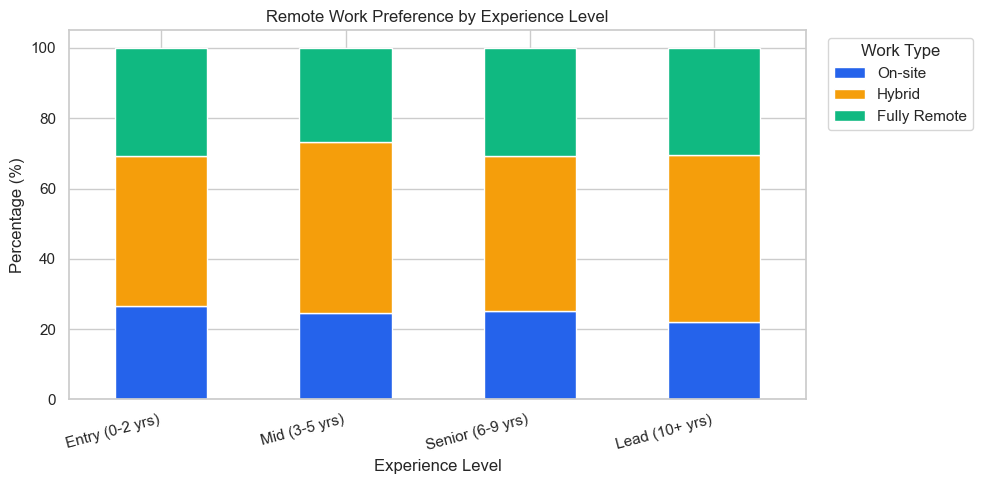

In [19]:
# Remote work preference by experience level
remote_by_exp = pd.crosstab(df['experience_level'], df['remote_work'], normalize='index') * 100
remote_by_exp = remote_by_exp.reindex(exp_order)[remote_order]

fig, ax = plt.subplots(figsize=(10, 5))
remote_by_exp.plot(kind='bar', stacked=True, color=PALETTE[:3], edgecolor='white', ax=ax)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Experience Level')
ax.set_title('Remote Work Preference by Experience Level')
ax.legend(title='Work Type', bbox_to_anchor=(1.02, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Demand & Growth Trends

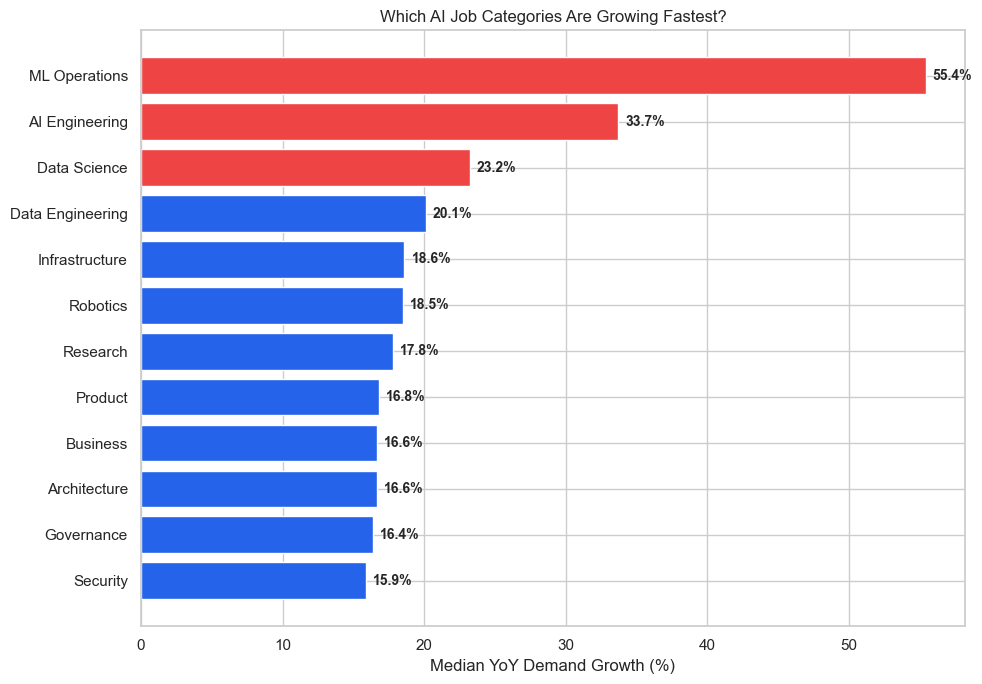

In [20]:
# Demand growth by job category
growth_by_cat = df.groupby('job_category')['demand_growth_yoy_pct'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[3] if val >= growth_by_cat.quantile(0.75) else PALETTE[0] for val in growth_by_cat.values]
ax.barh(growth_by_cat.index, growth_by_cat.values, color=colors, edgecolor='white')

for i, (cat, val) in enumerate(growth_by_cat.items()):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median YoY Demand Growth (%)')
ax.set_title('Which AI Job Categories Are Growing Fastest?')
plt.tight_layout()
plt.show()

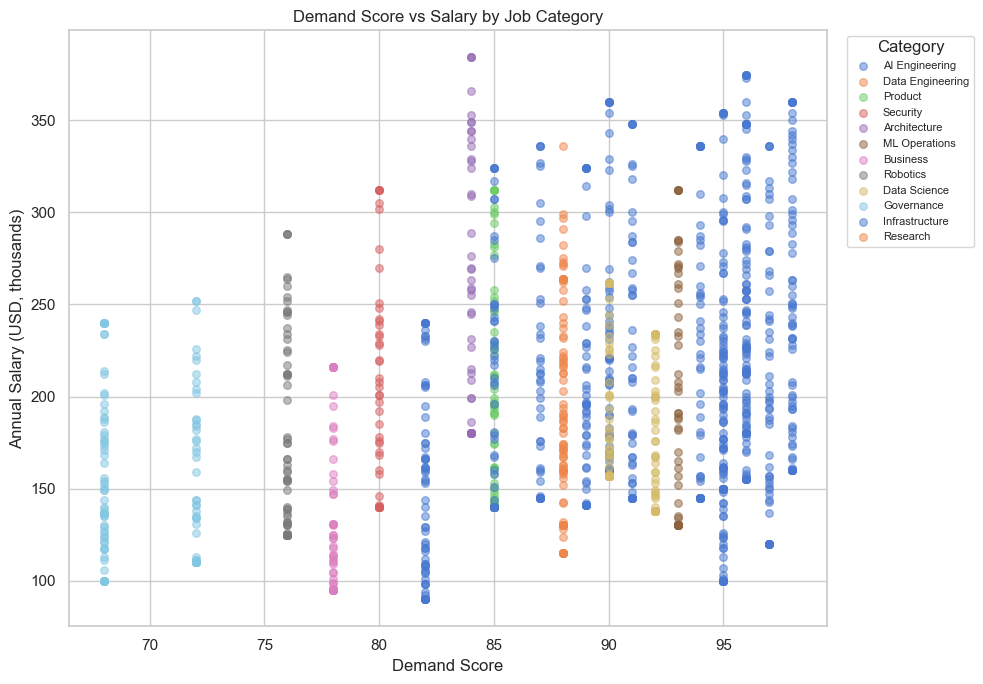

In [21]:
# Demand score vs Salary — scatter plot by category
fig, ax = plt.subplots(figsize=(10, 7))

categories = df['job_category'].unique()
palette_map = {cat: sns.color_palette('tab10', len(categories))[i] for i, cat in enumerate(categories)}

for cat in categories:
    subset = df[df['job_category'] == cat]
    ax.scatter(
        subset['demand_score'], subset['annual_salary_usd'] / 1000,
        label=cat, alpha=0.5, s=30
    )

ax.set_xlabel('Demand Score')
ax.set_ylabel('Annual Salary (USD, thousands)')
ax.set_title('Demand Score vs Salary by Job Category')
ax.legend(bbox_to_anchor=(1.02, 1), fontsize=8, title='Category')
plt.tight_layout()
plt.show()

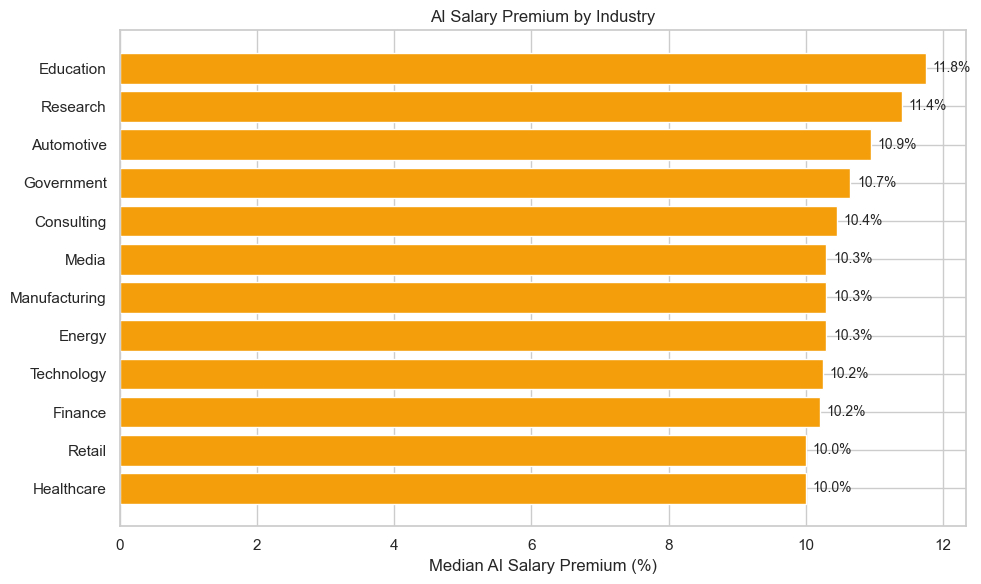

In [22]:
# AI salary premium by industry
premium_by_industry = df.groupby('industry')['ai_salary_premium_pct'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(premium_by_industry.index, premium_by_industry.values, color=PALETTE[1], edgecolor='white')

for i, (ind, val) in enumerate(premium_by_industry.items()):
    ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Median AI Salary Premium (%)')
ax.set_title('AI Salary Premium by Industry')
plt.tight_layout()
plt.show()

### 4.5 LLM Roles Deep Dive

With LLM-specific roles emerging as a distinct category, let's see how they compare.

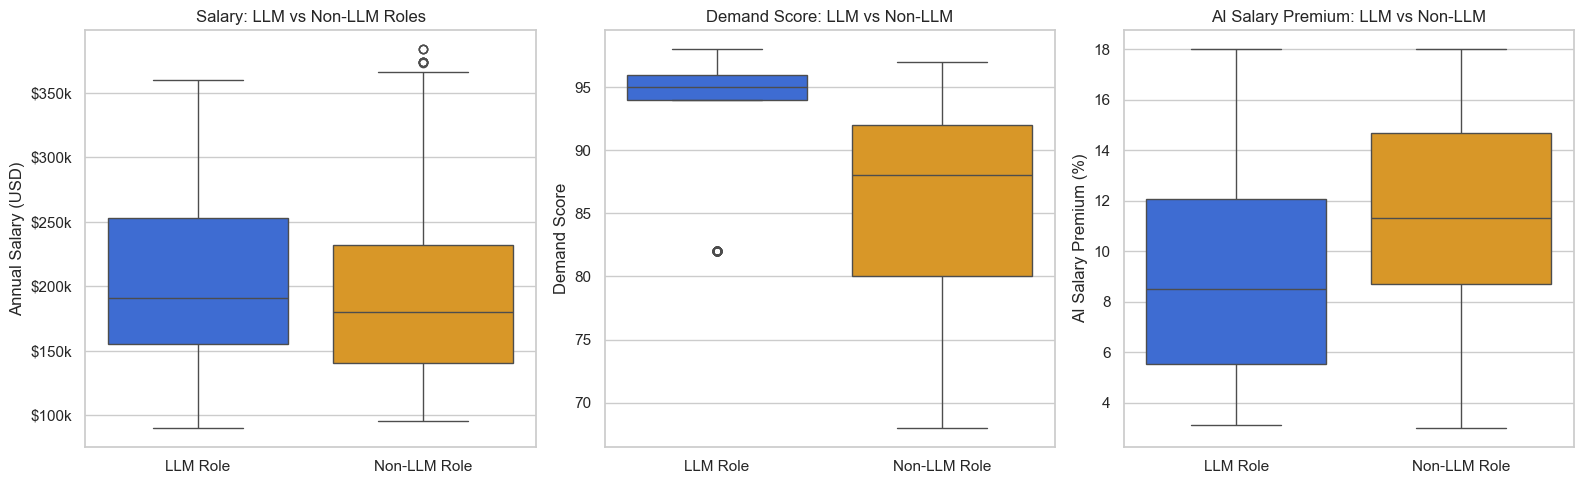


LLM vs Non-LLM — Median Comparison:
              median_salary  median_demand  median_premium  median_growth  \
is_llm_label                                                                
LLM Role          191,000.0           95.0             8.5           42.4   
Non-LLM Role      180,000.0           88.0            11.3           21.5   

              count  
is_llm_label         
LLM Role        327  
Non-LLM Role   1173  


In [23]:
# LLM vs Non-LLM comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Salary comparison
sns.boxplot(data=df, x='is_llm_label', y='annual_salary_usd', hue='is_llm_label', palette=[PALETTE[0], PALETTE[1]], legend=False, ax=axes[0])
axes[0].set_title('Salary: LLM vs Non-LLM Roles')
axes[0].set_xlabel('')
axes[0].set_ylabel('Annual Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Demand score comparison
sns.boxplot(data=df, x='is_llm_label', y='demand_score', hue='is_llm_label', palette=[PALETTE[0], PALETTE[1]], legend=False, ax=axes[1])
axes[1].set_title('Demand Score: LLM vs Non-LLM')
axes[1].set_xlabel('')
axes[1].set_ylabel('Demand Score')

# AI Premium comparison
sns.boxplot(data=df, x='is_llm_label', y='ai_salary_premium_pct', hue='is_llm_label', palette=[PALETTE[0], PALETTE[1]], legend=False, ax=axes[2])
axes[2].set_title('AI Salary Premium: LLM vs Non-LLM')
axes[2].set_xlabel('')
axes[2].set_ylabel('AI Salary Premium (%)')

plt.tight_layout()
plt.show()

# Summary stats
print('\nLLM vs Non-LLM — Median Comparison:')
comparison = df.groupby('is_llm_label').agg(
    median_salary=('annual_salary_usd', 'median'),
    median_demand=('demand_score', 'median'),
    median_premium=('ai_salary_premium_pct', 'median'),
    median_growth=('demand_growth_yoy_pct', 'median'),
    count=('annual_salary_usd', 'count')
)
print(comparison)

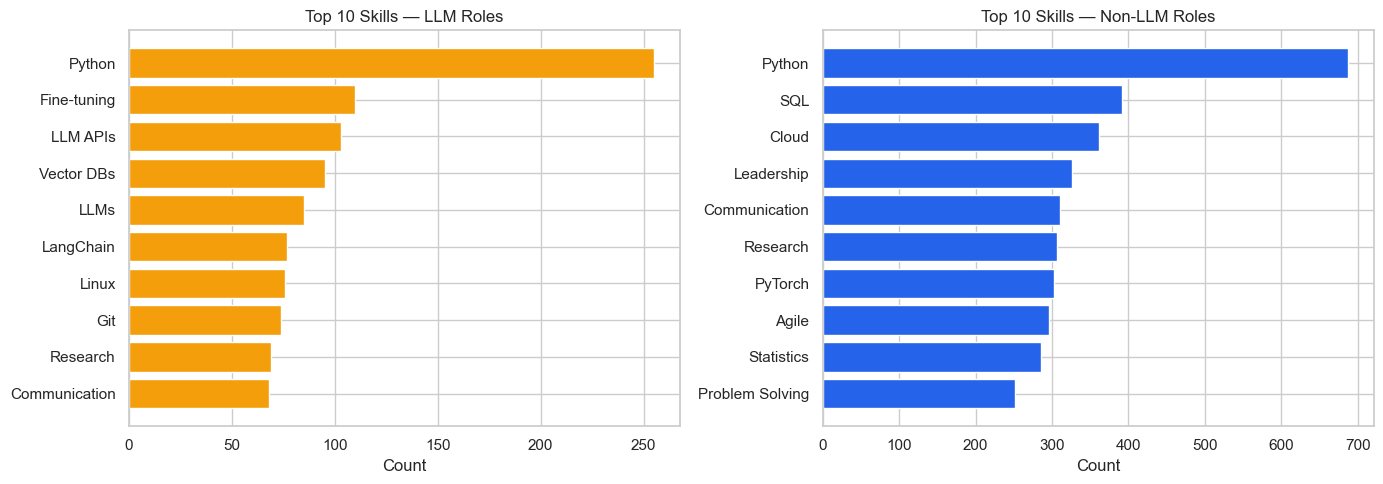

In [24]:
# Top skills in LLM roles vs Non-LLM roles
llm_skills = (
    skills_exploded[skills_exploded['is_llm_role'] == 1]['skills_list']
    .value_counts().head(10)
)
non_llm_skills = (
    skills_exploded[skills_exploded['is_llm_role'] == 0]['skills_list']
    .value_counts().head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(llm_skills.index[::-1], llm_skills.values[::-1], color=PALETTE[1])
axes[0].set_title('Top 10 Skills — LLM Roles')
axes[0].set_xlabel('Count')

axes[1].barh(non_llm_skills.index[::-1], non_llm_skills.values[::-1], color=PALETTE[0])
axes[1].set_title('Top 10 Skills — Non-LLM Roles')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

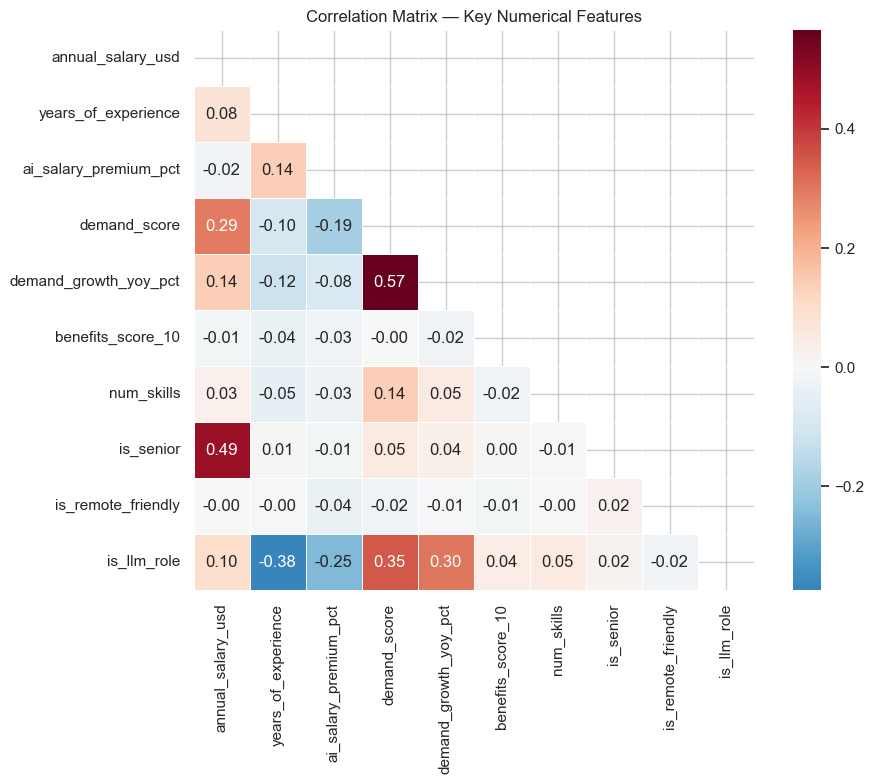

In [25]:
# Correlation heatmap for key numerical features
num_cols = [
    'annual_salary_usd', 'years_of_experience', 'ai_salary_premium_pct',
    'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
    'num_skills', 'is_senior', 'is_remote_friendly', 'is_llm_role'
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Key Numerical Features')
plt.tight_layout()
plt.show()

## 5. Key Takeaways

### Salary Landscape
- The median AI salary sits at **$180k**, with the bulk of roles falling between $100k–$300k. Architecture roles command the highest median pay at **$238k**, while Business-oriented AI roles sit at the lower end around **$116k**.
- Experience is the strongest salary driver — **Lead-level roles ($238k median)** earn roughly **64% more** than Entry-level positions ($145k). The biggest pay jump happens between Mid ($162k) and Senior ($208k), suggesting this is where specialisation starts to pay off.

### Skills & Demand
- **Python dominates**, appearing in 62.8% of all listings — nearly double the next most-requested skills (SQL, Cloud, and Leadership). For anyone entering the field, Python proficiency is essentially non-negotiable.
- Soft skills like Leadership, Communication, and Problem Solving rank surprisingly high (top 10), indicating that AI roles increasingly require cross-functional collaboration, not just technical depth.
- **ML Operations is the fastest-growing category** with a median YoY demand growth of **55.4%** — nearly double the next fastest (AI Engineering at 33.7%). This suggests the industry is shifting focus from building models to deploying and maintaining them at scale.

### Remote Work
- **Hybrid is the dominant work model** (45.7%), followed by Fully Remote (29.7%) and On-site (24.6%). Fully remote roles show a slightly wider salary spread, likely reflecting the global nature of remote hiring across different cost-of-living regions.

### LLM Roles — The Emerging Premium
- LLM-specific roles (22% of the dataset) carry a modest **salary premium of ~$11k** over non-LLM roles ($191k vs $180k median).
- Where LLM roles truly stand out is in **demand growth** — a median of **42.4% YoY** compared to 21.5% for non-LLM roles, suggesting that while the salary gap is still small, the hiring momentum behind these roles is accelerating rapidly.
- LLM roles also show higher median demand scores (95 vs 88), reinforcing that these are among the most sought-after positions in the current market.

### Limitations
- This dataset is likely **synthetic/generated** — the distributions across company size, education, and industry are unusually even, which would not occur in real-world job market data.

---
*Analysis by Devshree | Dataset: AI Job Market 2025–2026 (Kaggle)*